In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

display(Markdown("## 📊 DATASET 5: AMAZON PRODUCTS 2023"))

df5_cat = pd.read_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\amazon_products_2023\amazon_categories.csv")

print("Categories Shape:", df5_cat.shape)
df5_cat.head(10)

## 📊 DATASET 5: AMAZON PRODUCTS 2023

Categories Shape: (248, 2)


,id,category_name
0,1,Beading & Jewelry Making
1,2,Fabric Decorating
2,3,Knitting & Crochet Supplies
3,4,Printmaking Supplies
4,5,Scrapbooking & Stamping Supplies
5,6,Sewing Products
6,7,Craft & Hobby Fabric
7,8,Needlework Supplies
8,9,"Arts, Crafts & Sewing Storage"
9,10,"Painting, Drawing & Art Supplies"


In [3]:
display(Markdown("### 📥 Loading Full Products Dataset"))

df5 = pd.read_csv(
    r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\raw\amazon_products_2023\amazon_products.csv",
    low_memory=False
)

print("Shape:", df5.shape)
df5.head()

### 📥 Loading Full Products Dataset

Shape: (1426337, 11)


,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [4]:
display(Markdown("### 🔍 Step 1: Data Types & Structure"))
df5.info()

### 🔍 Step 1: Data Types & Structure

<class 'pandas.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1426337 non-null  str    
 1   title              1426336 non-null  str    
 2   imgUrl             1426337 non-null  str    
 3   productURL         1426337 non-null  str    
 4   stars              1426337 non-null  float64
 5   reviews            1426337 non-null  int64  
 6   price              1426337 non-null  float64
 7   listPrice          1426337 non-null  float64
 8   category_id        1426337 non-null  int64  
 9   isBestSeller       1426337 non-null  bool   
 10  boughtInLastMonth  1426337 non-null  int64  
dtypes: bool(1), float64(3), int64(3), str(4)
memory usage: 110.2 MB


In [5]:
display(Markdown("### ⚠️ Step 2: Missing Values Check"))
print(df5.isnull().sum())

### ⚠️ Step 2: Missing Values Check

asin                 0
title                1
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
dtype: int64


In [6]:
display(Markdown("### 🔁 Step 3: Duplicate Check"))
print("Duplicate rows:", df5.duplicated().sum())

### 🔁 Step 3: Duplicate Check

Duplicate rows: 0


In [7]:
display(Markdown("### 📈 Step 4: Summary Statistics"))
df5.describe()

### 📈 Step 4: Summary Statistics

,stars,reviews,price,listPrice,category_id,boughtInLastMonth
count,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06
mean,3.999512e+00,1.807508e+02,4.337540e+01,1.244916e+01,1.237409e+02,1.419823e+02
std,1.344292e+00,1.761453e+03,1.302893e+02,4.611198e+01,7.311273e+01,8.362720e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,4.100000e+00,0.000000e+00,1.199000e+01,0.000000e+00,6.500000e+01,0.000000e+00
50%,4.400000e+00,0.000000e+00,1.995000e+01,0.000000e+00,1.200000e+02,0.000000e+00
75%,4.600000e+00,0.000000e+00,3.599000e+01,0.000000e+00,1.760000e+02,5.000000e+01
max,5.000000e+00,3.465630e+05,1.973181e+04,9.999900e+02,2.700000e+02,1.000000e+05


In [8]:
display(Markdown("### ✅ Step 5: Validity Checks"))
print("Negative price:", (df5['price'] < 0).sum())
print("Zero price:", (df5['price'] == 0).sum())
print("Negative listPrice:", (df5['listPrice'] < 0).sum())
print("Negative reviews:", (df5['reviews'] < 0).sum())
print("Negative stars:", (df5['stars'] < 0).sum())
print("Stars > 5:", (df5['stars'] > 5).sum())
print("Unique category_id:", df5['category_id'].nunique())
print("isBestSeller values:", df5['isBestSeller'].unique())

### ✅ Step 5: Validity Checks

Negative price: 0
Zero price: 32772
Negative listPrice: 0
Negative reviews: 0
Negative stars: 0
Stars > 5: 0
Unique category_id: 248
isBestSeller values: [False  True]


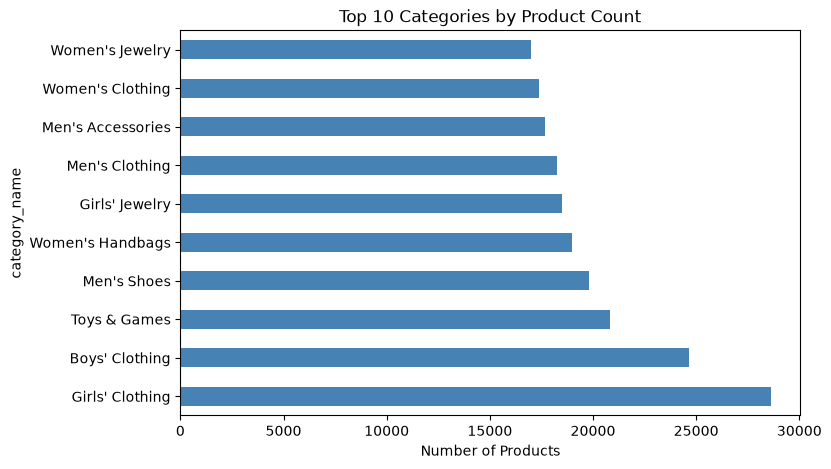

In [9]:
df5_temp = df5.merge(df5_cat.rename(columns={'id': 'category_id'}), on='category_id', how='left')

plt.figure(figsize=(8,5))
df5_temp['category_name'].value_counts().head(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Categories by Product Count')
plt.xlabel('Number of Products')
plt.show()

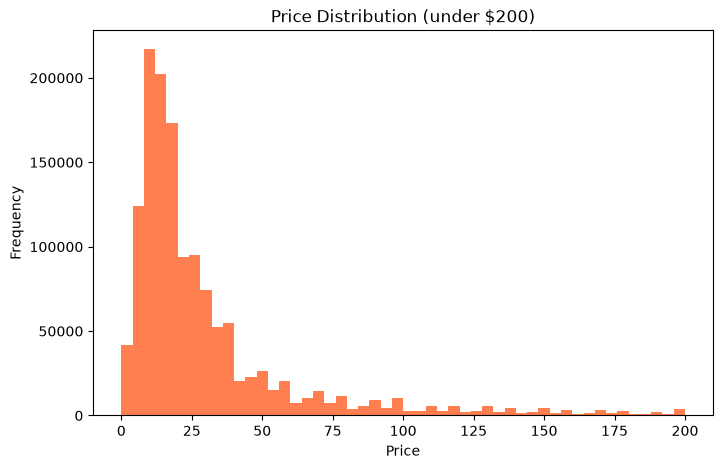

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df5['price'], bins=50, range=(0,200), color='coral')
plt.title('Price Distribution (under $200)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

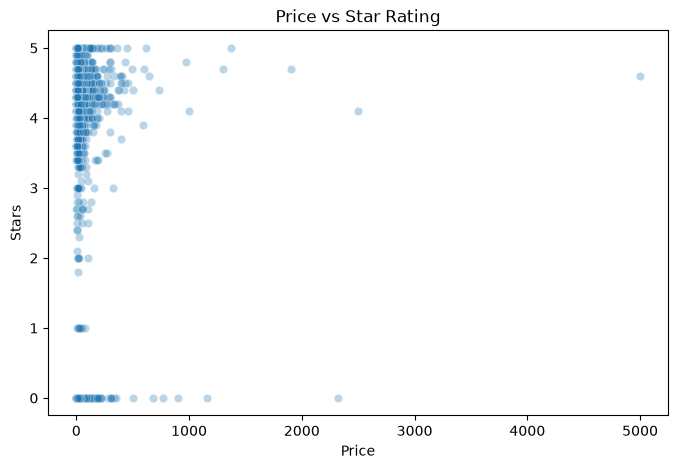

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df5.sample(3000), x='price', y='stars', alpha=0.3)
plt.title('Price vs Star Rating')
plt.xlabel('Price')
plt.ylabel('Stars')
plt.show()

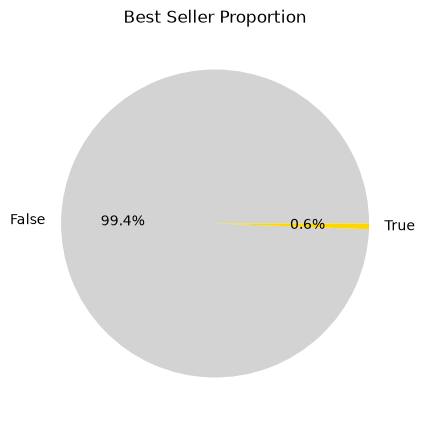

In [12]:
plt.figure(figsize=(8,5))
df5['isBestSeller'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgray','gold'])
plt.title('Best Seller Proportion')
plt.ylabel('')
plt.show()

### 🎨 Step 6: Visual EDA

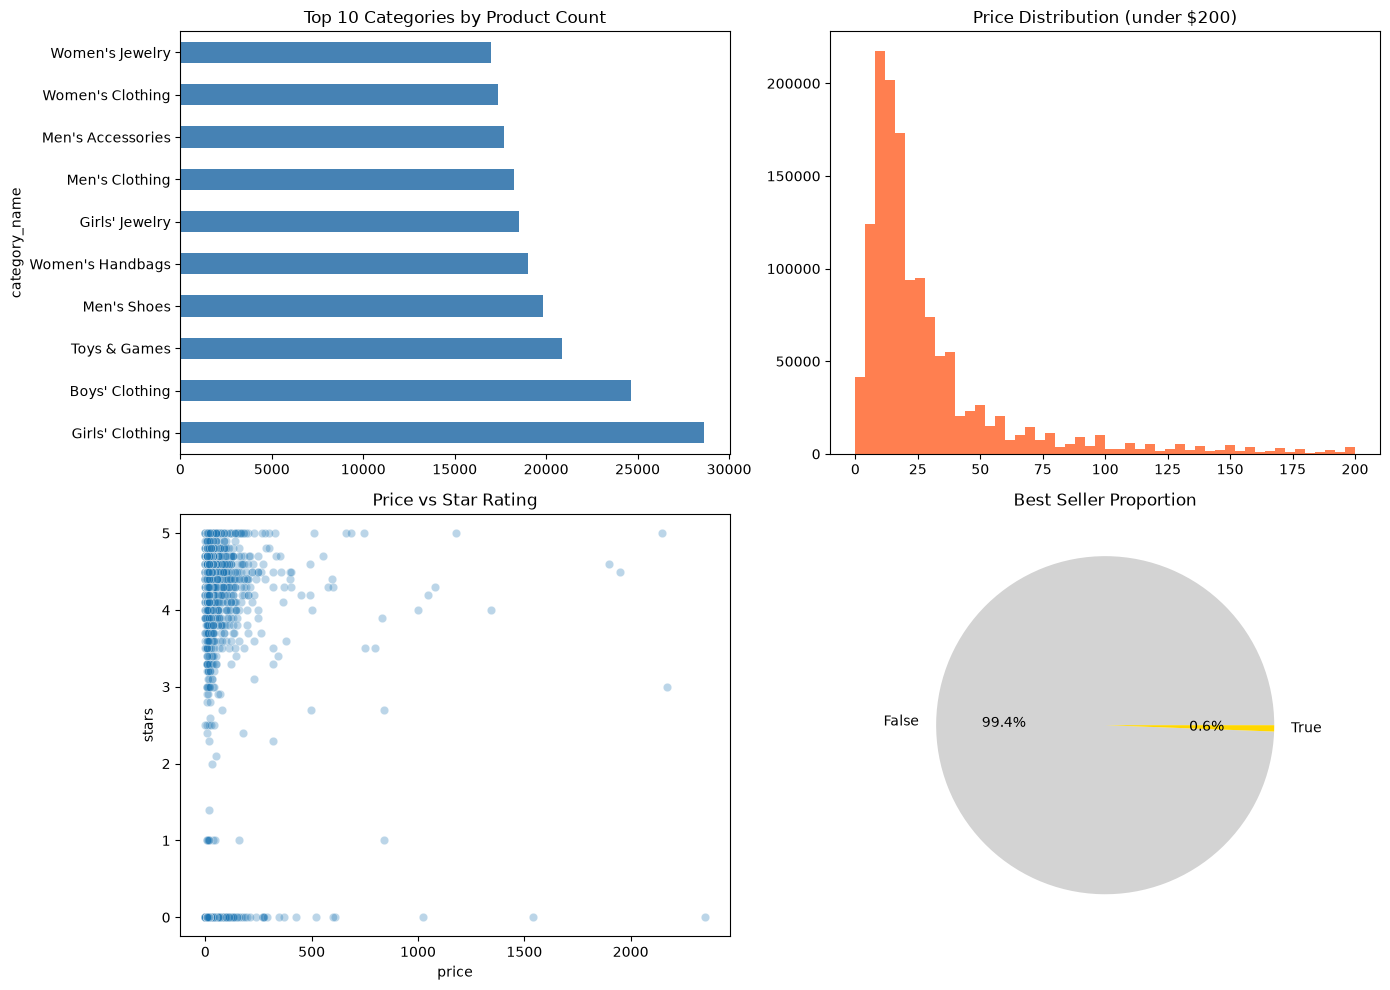

In [13]:
display(Markdown("### 🎨 Step 6: Visual EDA"))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df5_temp['category_name'].value_counts().head(10).plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 10 Categories by Product Count')

axes[0,1].hist(df5['price'], bins=50, range=(0,200), color='coral')
axes[0,1].set_title('Price Distribution (under $200)')

sns.scatterplot(data=df5.sample(3000), x='price', y='stars', alpha=0.3, ax=axes[1,0])
axes[1,0].set_title('Price vs Star Rating')

df5['isBestSeller'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', colors=['lightgray','gold'])
axes[1,1].set_title('Best Seller Proportion')

plt.tight_layout()
plt.show()

In [14]:
display(Markdown("### 🧹 Step 7: Data Cleaning"))

df5 = df5[df5['price'] > 0]
df5 = df5.dropna(subset=['title'])
df5_cat_renamed = df5_cat.rename(columns={'id': 'category_id', 'category_name': 'category_name'})
df5 = df5.merge(df5_cat_renamed, on='category_id', how='left')

print("Shape after cleaning:", df5.shape)
print("\nMissing values now:")
print(df5.isnull().sum())

### 🧹 Step 7: Data Cleaning

Shape after cleaning: (1393564, 12)

Missing values now:
asin                 0
title                0
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
category_name        0
dtype: int64


In [15]:
display(Markdown("### 💾 Step 8: Save Cleaned Dataset"))

df5.to_csv(r"C:\Users\sobhi\Downloads\PRICEPIOLET AI\data\processed_data\amazon_products_clean.csv", index=False)

print("Saved successfully!")
print("Final shape:", df5.shape)

### 💾 Step 8: Save Cleaned Dataset

Saved successfully!
Final shape: (1393564, 12)
